# Image Segmentation and Morphological Processing Workshop
## CMSC 178IP - Digital Image Processing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yourusername/CMSC178IP/blob/main/08-SegmentationMorphology/notebooks/segmentation_morphology_workshop.ipynb)

### Workshop Objectives
By the end of this workshop, you will be able to:
1. Apply various thresholding methods for image segmentation
2. Implement region-based segmentation techniques
3. Perform binary morphological operations (erosion, dilation, opening, closing)
4. Apply grayscale morphology for image enhancement
5. Combine segmentation and morphology for practical applications

**Duration:** 45-60 minutes including hands-on activities


In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, morphology, segmentation, measure, color, feature
from skimage.morphology import disk, square, diamond, remove_small_objects, remove_small_holes
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.3.3


## Part 1: Thresholding Methods

Thresholding is the simplest form of image segmentation, converting grayscale images to binary by selecting a threshold value.

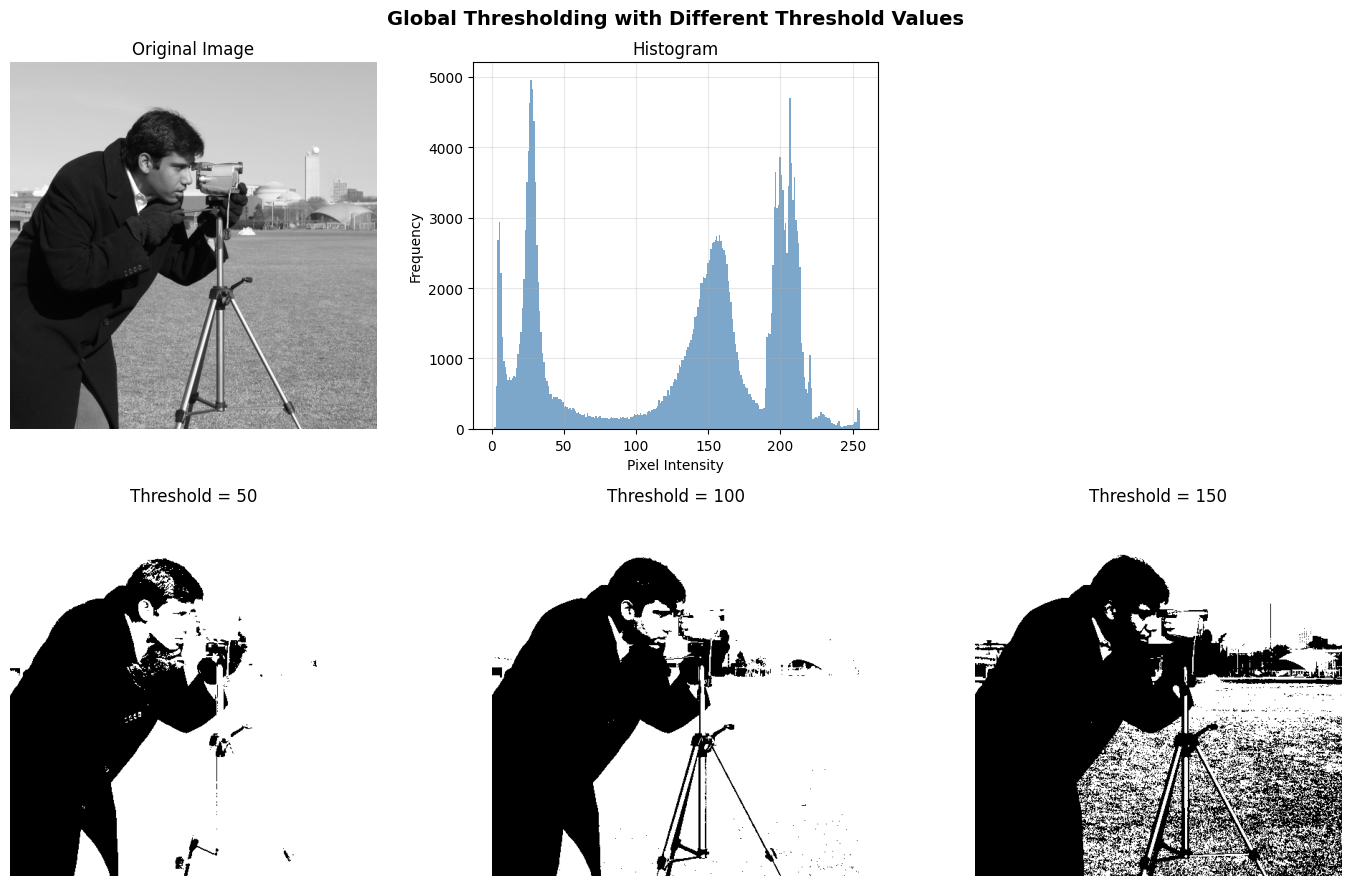

Image shape: (512, 512)
Intensity range: [0, 255]


In [2]:
# Load sample image
image = data.camera()

# Apply different threshold values
thresh_values = [50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Global Thresholding with Different Threshold Values', fontsize=14, fontweight='bold')

# Original image
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Histogram
axes[0, 1].hist(image.ravel(), bins=256, color='steelblue', alpha=0.7)
axes[0, 1].set_title('Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# Empty subplot
axes[0, 2].axis('off')

# Apply thresholds
for idx, thresh in enumerate(thresh_values):
    binary = image > thresh
    row = 1
    col = idx
    axes[row, col].imshow(binary, cmap='gray')
    axes[row, col].set_title(f'Threshold = {thresh}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Intensity range: [{image.min()}, {image.max()}]")

### Otsu's Automatic Thresholding

Otsu's method automatically determines the optimal threshold by maximizing between-class variance.

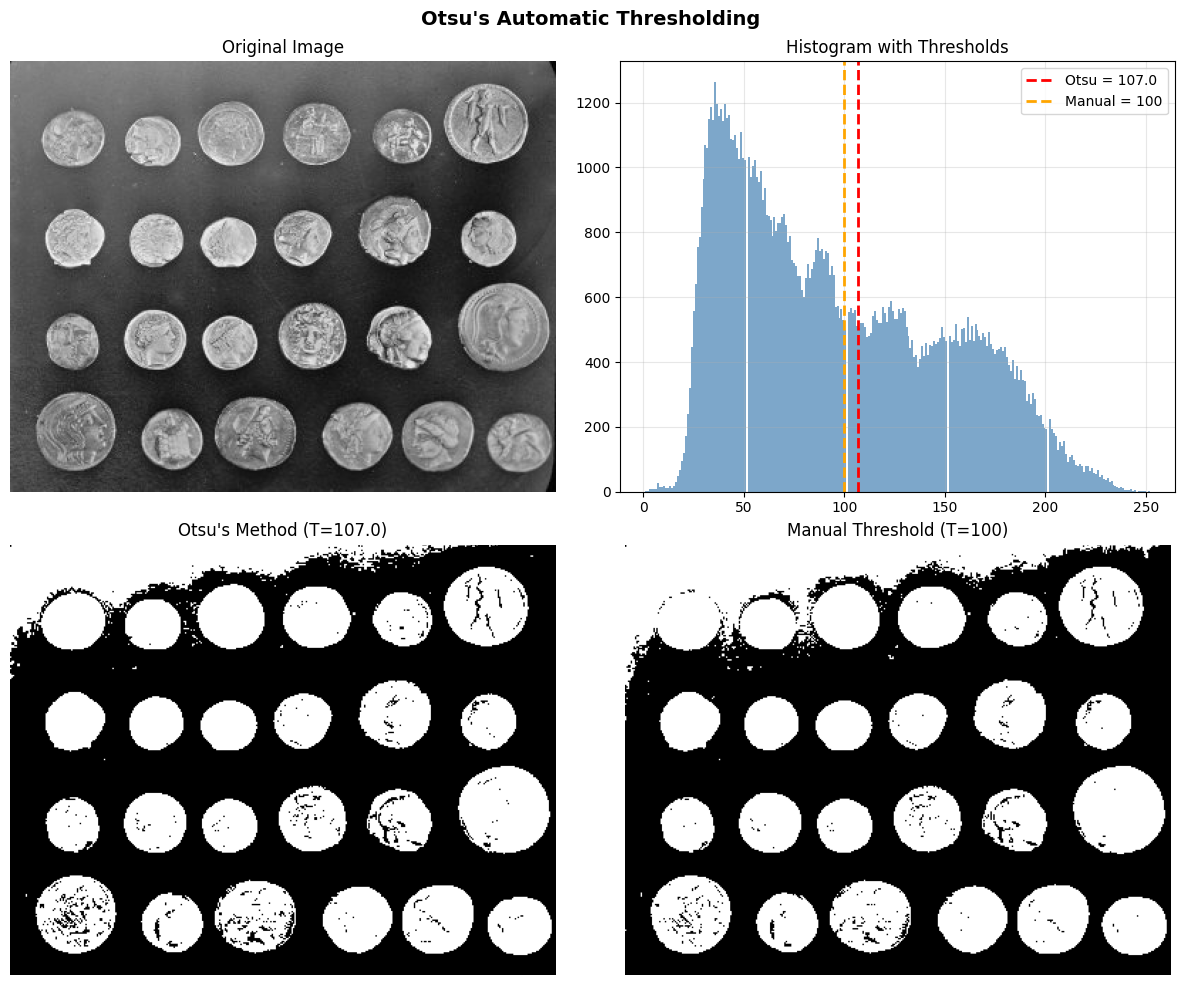

Otsu's optimal threshold: 107.00
Number of foreground pixels (Otsu): 45,117
Number of foreground pixels (Manual): 48,864


In [3]:
# Otsu's thresholding
image = data.coins()
otsu_thresh = filters.threshold_otsu(image)
binary_otsu = image > otsu_thresh

# Manual threshold for comparison
manual_thresh = 100
binary_manual = image > manual_thresh

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Otsu's Automatic Thresholding", fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Histogram with Otsu threshold
axes[0, 1].hist(image.ravel(), bins=256, color='steelblue', alpha=0.7)
axes[0, 1].axvline(otsu_thresh, color='red', linestyle='--', linewidth=2, label=f'Otsu = {otsu_thresh:.1f}')
axes[0, 1].axvline(manual_thresh, color='orange', linestyle='--', linewidth=2, label=f'Manual = {manual_thresh}')
axes[0, 1].set_title('Histogram with Thresholds')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Otsu result
axes[1, 0].imshow(binary_otsu, cmap='gray')
axes[1, 0].set_title(f"Otsu's Method (T={otsu_thresh:.1f})")
axes[1, 0].axis('off')

# Manual result
axes[1, 1].imshow(binary_manual, cmap='gray')
axes[1, 1].set_title(f'Manual Threshold (T={manual_thresh})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Otsu's optimal threshold: {otsu_thresh:.2f}")
print(f"Number of foreground pixels (Otsu): {binary_otsu.sum():,}")
print(f"Number of foreground pixels (Manual): {binary_manual.sum():,}")

### Local (Adaptive) Thresholding

Local thresholding computes threshold values locally, which is useful for images with non-uniform illumination.

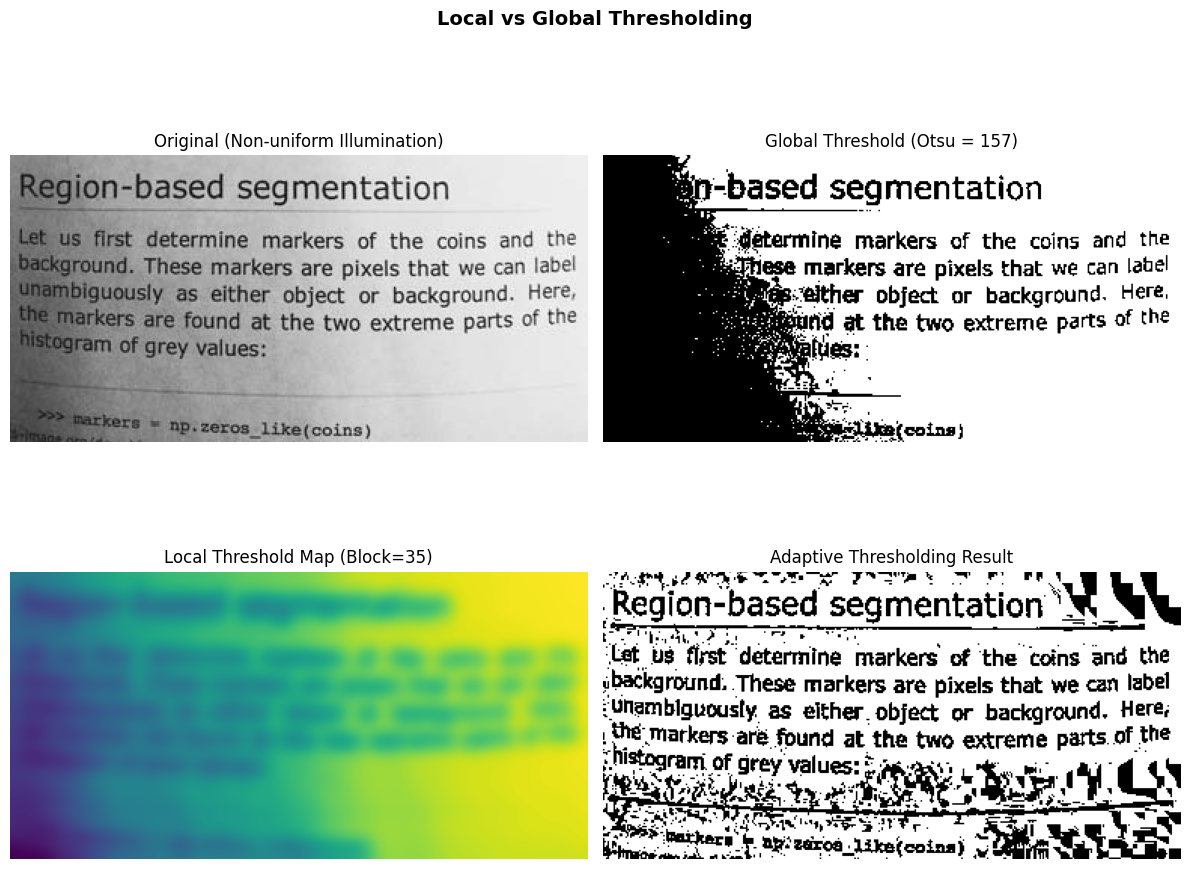

Notice how local thresholding preserves text in varying illumination!


In [4]:
# Local thresholding demonstration
image = data.page()

# Global threshold
global_thresh = filters.threshold_otsu(image)
binary_global = image > global_thresh

# Local threshold
block_size = 35
local_thresh = filters.threshold_local(image, block_size=block_size)
binary_local = image > local_thresh

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Local vs Global Thresholding', fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original (Non-uniform Illumination)')
axes[0, 0].axis('off')

# Global threshold result
axes[0, 1].imshow(binary_global, cmap='gray')
axes[0, 1].set_title(f'Global Threshold (Otsu = {global_thresh:.0f})')
axes[0, 1].axis('off')

# Local threshold map
axes[1, 0].imshow(local_thresh, cmap='viridis')
axes[1, 0].set_title(f'Local Threshold Map (Block={block_size})')
axes[1, 0].axis('off')

# Local threshold result
axes[1, 1].imshow(binary_local, cmap='gray')
axes[1, 1].set_title('Adaptive Thresholding Result')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Notice how local thresholding preserves text in varying illumination!")

## Part 2: Region-Based Segmentation

### Watershed Segmentation

Watershed algorithm treats the image as a topographic surface and segments it by simulating flooding from local minima.

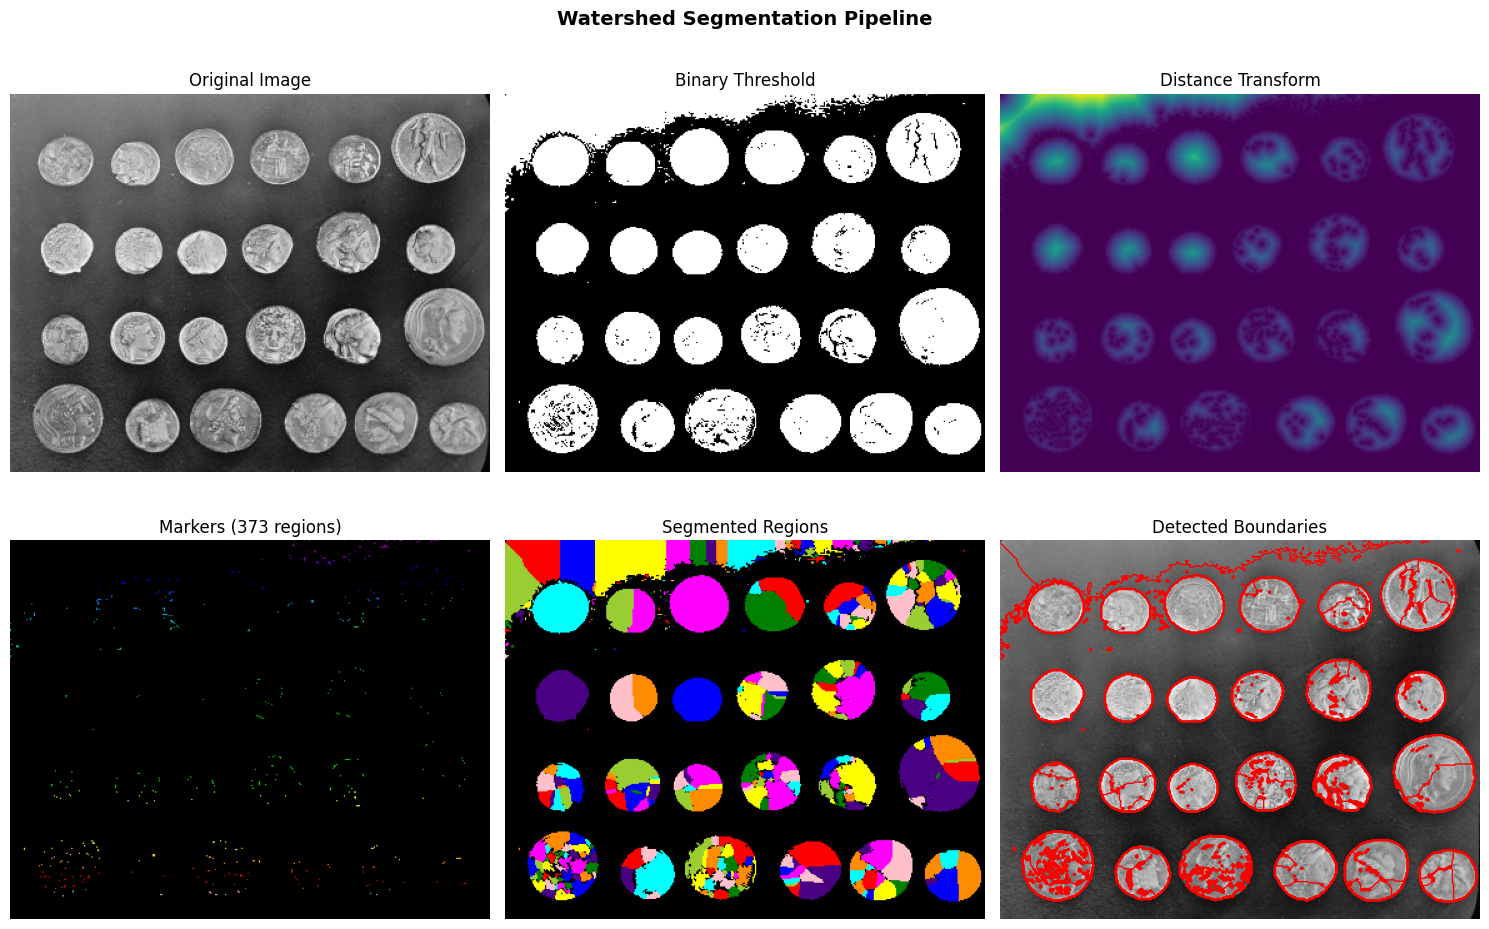

Number of detected objects: 373


In [5]:
# Watershed segmentation
image = data.coins()

# Threshold
binary = image > filters.threshold_otsu(image)

# Distance transform
distance = ndimage.distance_transform_edt(binary)

# Find local maxima for markers
local_max = morphology.local_maxima(distance)
markers = measure.label(local_max)

# Apply watershed
labels = segmentation.watershed(-distance, markers, mask=binary)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Watershed Segmentation Pipeline', fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Binary
axes[0, 1].imshow(binary, cmap='gray')
axes[0, 1].set_title('Binary Threshold')
axes[0, 1].axis('off')

# Distance transform
axes[0, 2].imshow(distance, cmap='viridis')
axes[0, 2].set_title('Distance Transform')
axes[0, 2].axis('off')

# Markers
axes[1, 0].imshow(markers, cmap='nipy_spectral')
axes[1, 0].set_title(f'Markers ({markers.max()} regions)')
axes[1, 0].axis('off')

# Watershed result (colored)
axes[1, 1].imshow(color.label2rgb(labels, bg_label=0))
axes[1, 1].set_title('Segmented Regions')
axes[1, 1].axis('off')

# Boundaries overlay
axes[1, 2].imshow(image, cmap='gray')
axes[1, 2].contour(labels, colors='red', linewidths=1)
axes[1, 2].set_title('Detected Boundaries')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"Number of detected objects: {labels.max()}")

## Part 3: Binary Morphological Operations

Morphology operations use structuring elements to probe and modify image structures.

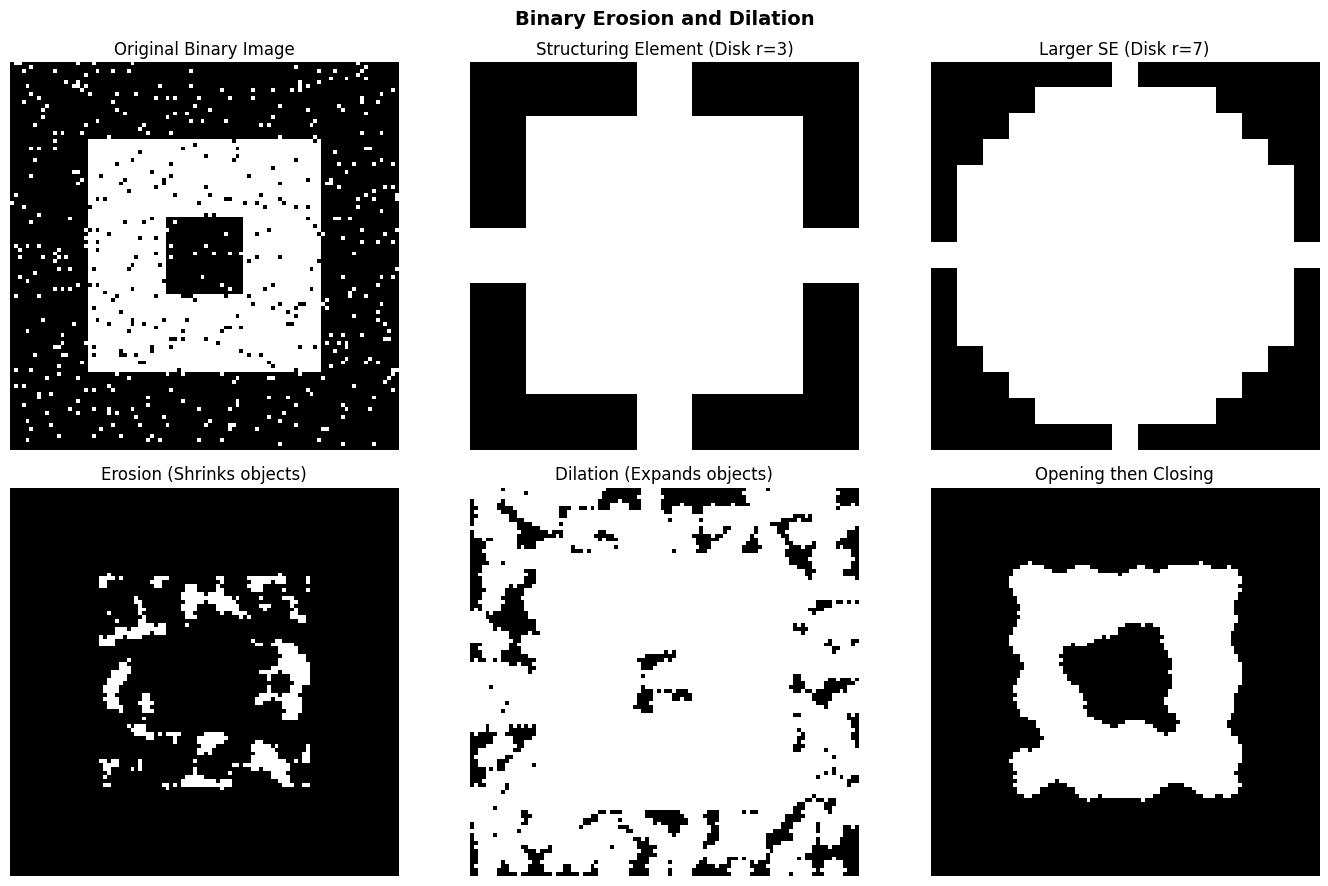

Erosion removes pixels from object boundaries
Dilation adds pixels to object boundaries


In [6]:
# Binary erosion and dilation
# Create binary test image
test_image = np.zeros((100, 100), dtype=bool)
test_image[20:80, 20:80] = True
test_image[40:60, 40:60] = False

# Add some noise
noise_mask = np.random.random(test_image.shape) > 0.95
test_image[noise_mask] = ~test_image[noise_mask]

# Define structuring elements
selem_small = disk(3)
selem_large = disk(7)

# Apply operations
eroded = morphology.binary_erosion(test_image, selem_small)
dilated = morphology.binary_dilation(test_image, selem_small)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Binary Erosion and Dilation', fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(test_image, cmap='gray')
axes[0, 0].set_title('Original Binary Image')
axes[0, 0].axis('off')

# Structuring element
axes[0, 1].imshow(selem_small, cmap='gray')
axes[0, 1].set_title('Structuring Element (Disk r=3)')
axes[0, 1].axis('off')

# Larger SE
axes[0, 2].imshow(selem_large, cmap='gray')
axes[0, 2].set_title('Larger SE (Disk r=7)')
axes[0, 2].axis('off')

# Eroded
axes[1, 0].imshow(eroded, cmap='gray')
axes[1, 0].set_title('Erosion (Shrinks objects)')
axes[1, 0].axis('off')

# Dilated
axes[1, 1].imshow(dilated, cmap='gray')
axes[1, 1].set_title('Dilation (Expands objects)')
axes[1, 1].axis('off')

# Both applied
axes[1, 2].imshow(morphology.binary_closing(morphology.binary_opening(test_image, selem_small), selem_small), cmap='gray')
axes[1, 2].set_title('Opening then Closing')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("Erosion removes pixels from object boundaries")
print("Dilation adds pixels to object boundaries")

### Opening and Closing

- **Opening** (erosion → dilation): Removes small bright regions
- **Closing** (dilation → erosion): Fills small dark regions

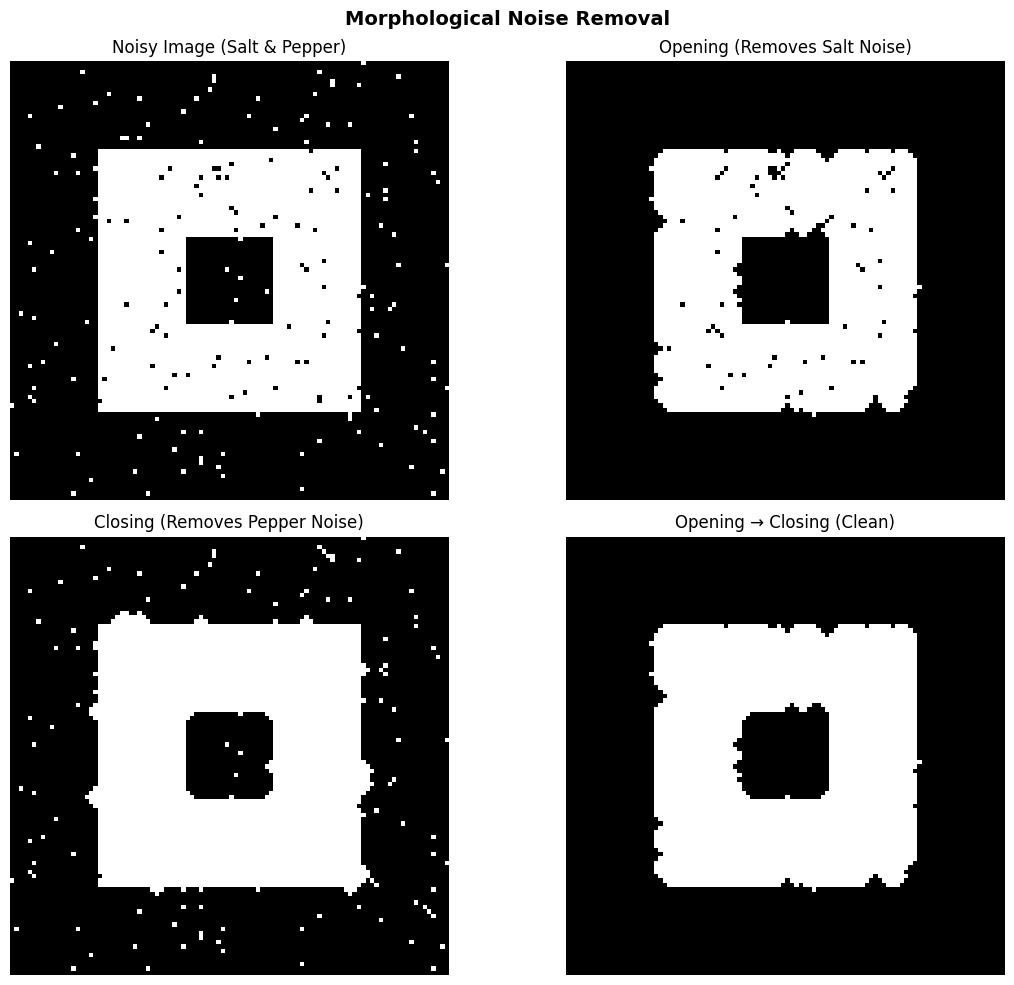

Original noise pixels: 633
After cleaning: 566


In [7]:
# Opening and closing for noise removal
# Create noisy image
noisy_image = np.zeros((100, 100), dtype=bool)
noisy_image[20:80, 20:80] = True
noisy_image[40:60, 40:60] = False

# Add salt and pepper noise
salt = np.random.random(noisy_image.shape) > 0.98
pepper = np.random.random(noisy_image.shape) > 0.98
noisy_image[salt & ~noisy_image] = True
noisy_image[pepper & noisy_image] = False

# Apply morphological operations
selem = disk(2)
opened = morphology.binary_opening(noisy_image, selem)
closed = morphology.binary_closing(noisy_image, selem)
cleaned = morphology.binary_closing(morphology.binary_opening(noisy_image, selem), selem)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Morphological Noise Removal', fontsize=14, fontweight='bold')

# Noisy
axes[0, 0].imshow(noisy_image, cmap='gray')
axes[0, 0].set_title('Noisy Image (Salt & Pepper)')
axes[0, 0].axis('off')

# Opening
axes[0, 1].imshow(opened, cmap='gray')
axes[0, 1].set_title('Opening (Removes Salt Noise)')
axes[0, 1].axis('off')

# Closing
axes[1, 0].imshow(closed, cmap='gray')
axes[1, 0].set_title('Closing (Removes Pepper Noise)')
axes[1, 0].axis('off')

# Both
axes[1, 1].imshow(cleaned, cmap='gray')
axes[1, 1].set_title('Opening → Closing (Clean)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Original noise pixels: {np.sum(noisy_image != test_image[:100, :100])}")
print(f"After cleaning: {np.sum(cleaned != test_image[:100, :100])}")

## Part 4: Grayscale Morphological Operations

Morphology extends to grayscale images, where erosion computes local minima and dilation computes local maxima.

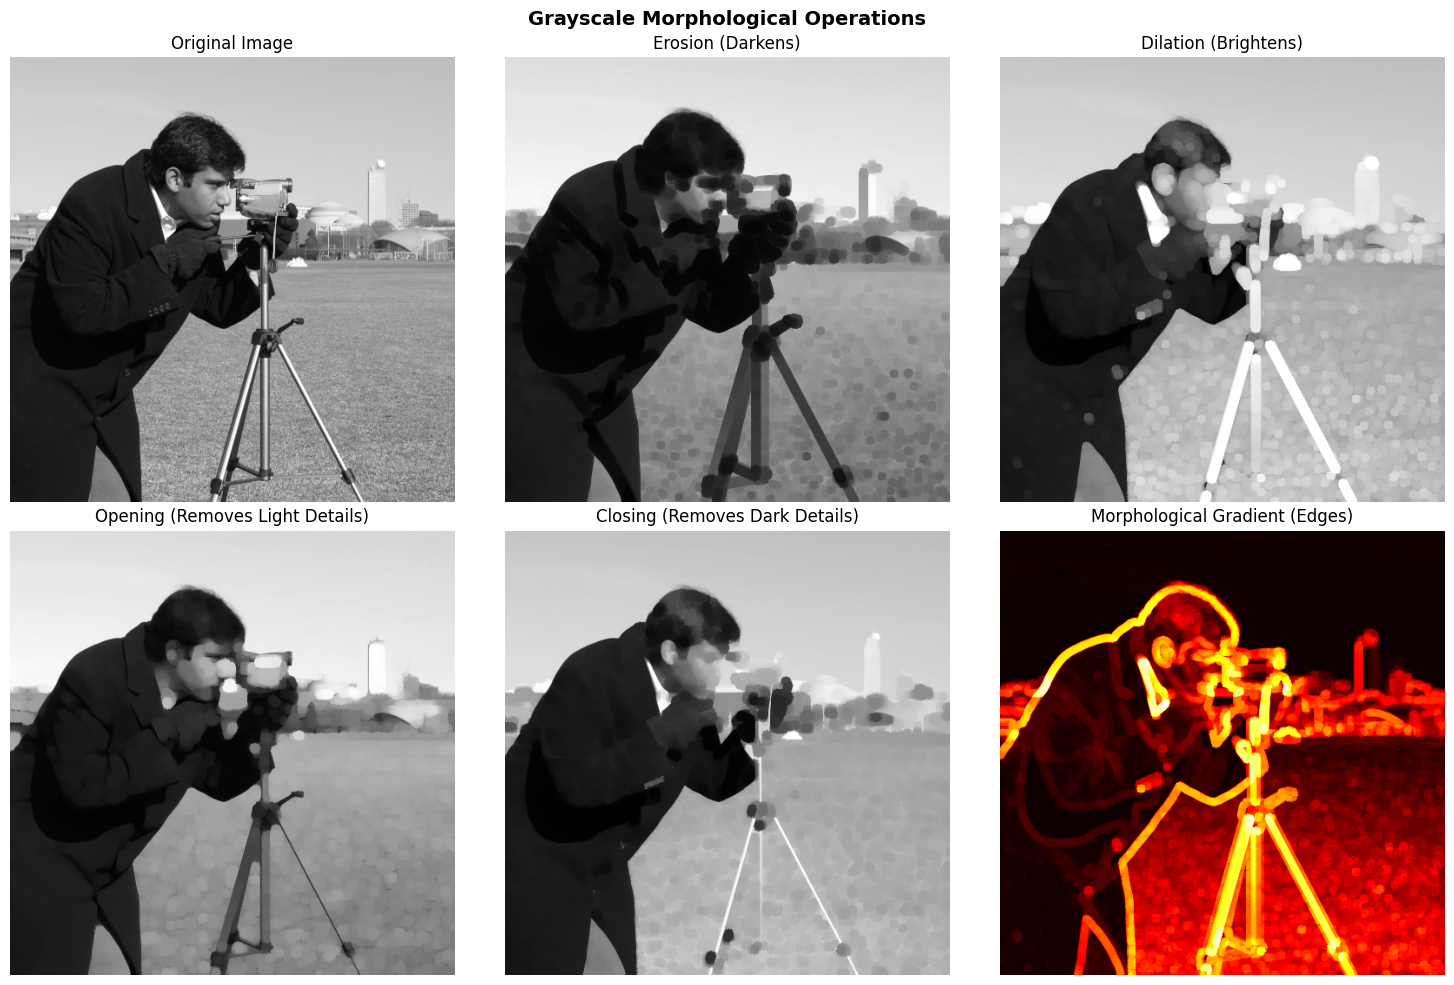

Grayscale morphology operates on intensity values
Gradient range: [1, 248]


In [8]:
# Grayscale morphology
image = data.camera()
selem = disk(5)

# Basic operations
eroded = morphology.erosion(image, selem)
dilated = morphology.dilation(image, selem)
opened = morphology.opening(image, selem)
closed = morphology.closing(image, selem)

# Morphological gradient
gradient = dilated - eroded

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Grayscale Morphological Operations', fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Erosion
axes[0, 1].imshow(eroded, cmap='gray')
axes[0, 1].set_title('Erosion (Darkens)')
axes[0, 1].axis('off')

# Dilation
axes[0, 2].imshow(dilated, cmap='gray')
axes[0, 2].set_title('Dilation (Brightens)')
axes[0, 2].axis('off')

# Opening
axes[1, 0].imshow(opened, cmap='gray')
axes[1, 0].set_title('Opening (Removes Light Details)')
axes[1, 0].axis('off')

# Closing
axes[1, 1].imshow(closed, cmap='gray')
axes[1, 1].set_title('Closing (Removes Dark Details)')
axes[1, 1].axis('off')

# Gradient
axes[1, 2].imshow(gradient, cmap='hot')
axes[1, 2].set_title('Morphological Gradient (Edges)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("Grayscale morphology operates on intensity values")
print(f"Gradient range: [{gradient.min()}, {gradient.max()}]")

### Top-Hat Transforms

Top-hat transforms extract features by comparing original images with opened/closed versions.

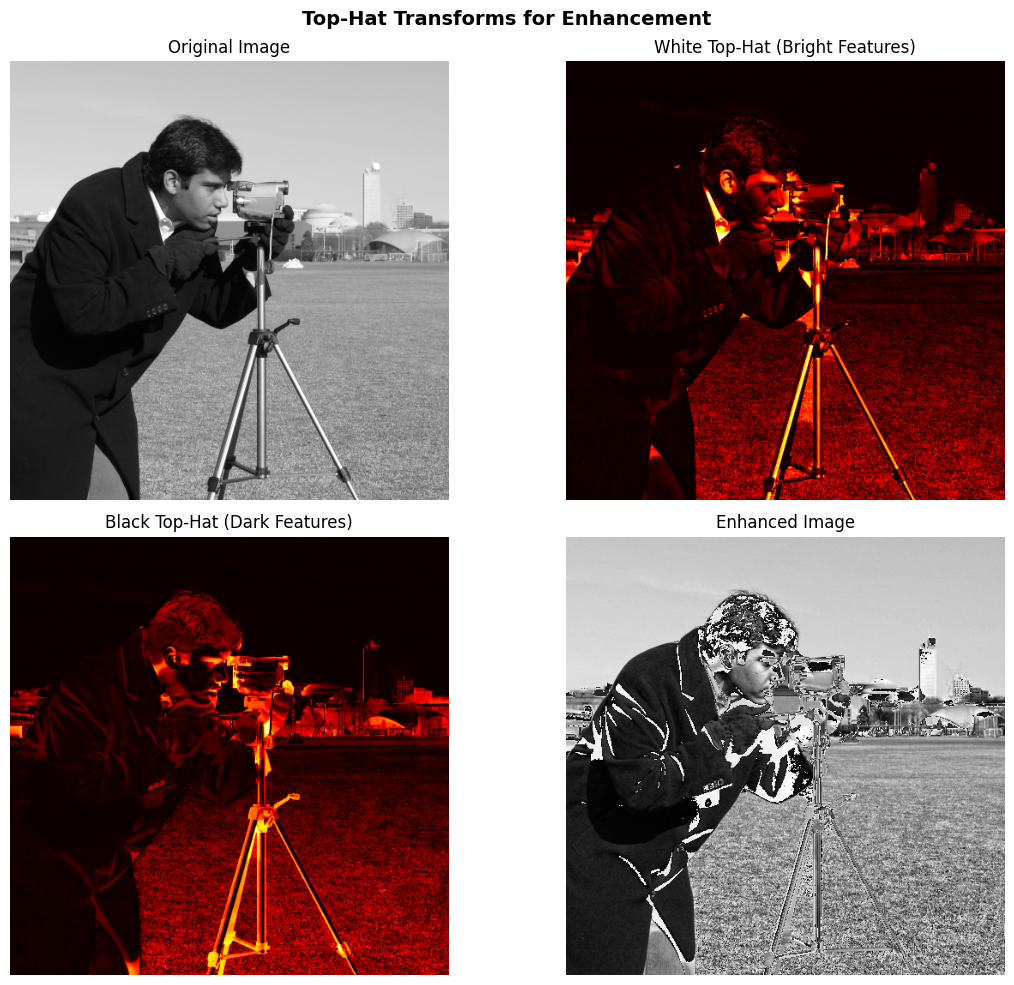

Top-hat transforms enhance details at specific scales


In [9]:
# Top-hat transforms
image = data.camera()
selem = disk(10)

# Top-hat transforms
white_tophat = morphology.white_tophat(image, selem)
black_tophat = morphology.black_tophat(image, selem)

# Enhanced image
enhanced = image + white_tophat - black_tophat

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Top-Hat Transforms for Enhancement', fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# White top-hat
axes[0, 1].imshow(white_tophat, cmap='hot')
axes[0, 1].set_title('White Top-Hat (Bright Features)')
axes[0, 1].axis('off')

# Black top-hat
axes[1, 0].imshow(black_tophat, cmap='hot')
axes[1, 0].set_title('Black Top-Hat (Dark Features)')
axes[1, 0].axis('off')

# Enhanced
axes[1, 1].imshow(enhanced, cmap='gray')
axes[1, 1].set_title('Enhanced Image')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Top-hat transforms enhance details at specific scales")

## Part 5: Student Activity (15 minutes)

### Challenge: Object Counting and Analysis

Your task is to segment the coins image and count the number of coins, as well as compute properties of each coin.

**Steps:**
1. Load the `data.coins()` image
2. Apply appropriate thresholding (try Otsu's method)
3. Clean the binary image using morphological operations
4. Separate touching coins using watershed
5. Count the coins and compute their areas
6. Visualize the results with labeled coins

**Bonus challenges:**
- Filter out coins smaller than a threshold
- Compute the average coin area
- Highlight the largest coin

In [10]:
# Your code here
# TODO: Implement coin counting and analysis

# Step 1: Load image
image = data.coins()

# Step 2: Apply thresholding
# Your code here

# Step 3: Clean with morphology
# Your code here

# Step 4: Apply watershed
# Your code here

# Step 5: Analyze regions
# Your code here

# Step 6: Visualize results
# Your code here


### Solution (Hidden - Try the activity first!)

Click below to reveal the solution.

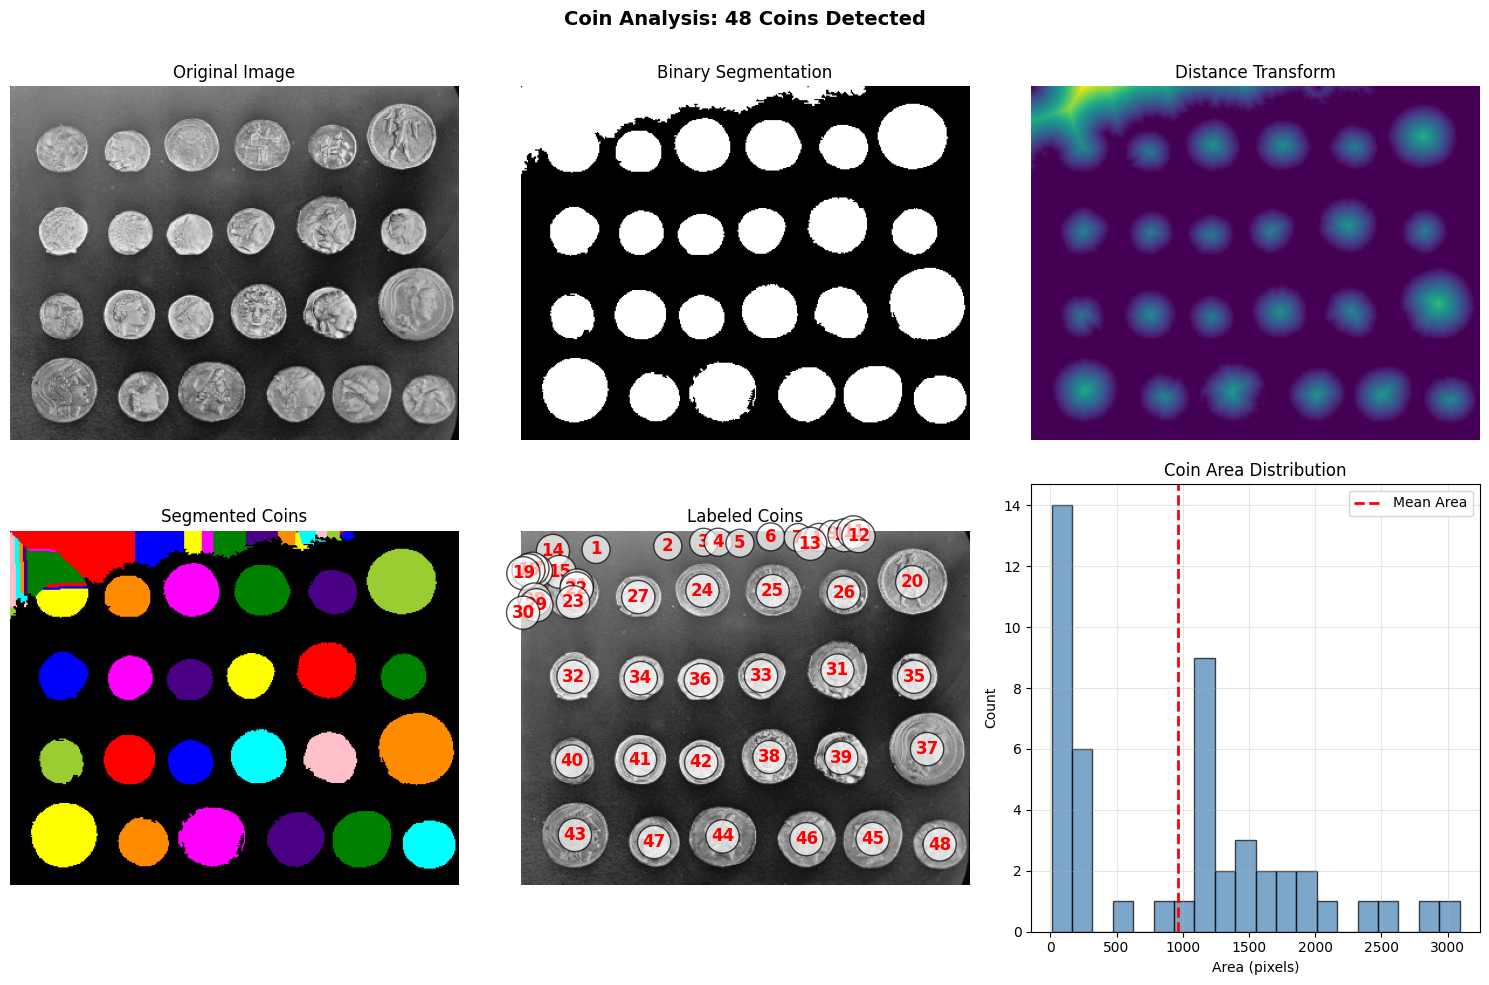


COIN ANALYSIS RESULTS
Total coins detected: 48
Average coin area: 967 pixels
Smallest coin: 10 pixels
Largest coin: 3091 pixels
Standard deviation: 846 pixels

Largest coin is #37 with area 3091 pixels


In [11]:
# SOLUTION - Complete coin counting and analysis

# Step 1: Load and preprocess
image = data.coins()

# Step 2: Thresholding
thresh = filters.threshold_otsu(image)
binary = image > thresh

# Step 3: Morphological cleaning
binary_cleaned = remove_small_objects(binary, min_size=50)
binary_filled = ndimage.binary_fill_holes(binary_cleaned)

# Step 4: Watershed for separation
distance = ndimage.distance_transform_edt(binary_filled)
local_max = morphology.local_maxima(distance)
markers = measure.label(local_max)
labels = segmentation.watershed(-distance, markers, mask=binary_filled)

# Step 5: Region analysis
regions = measure.regionprops(labels)
areas = [r.area for r in regions]
num_coins = len(regions)

# Step 6: Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Coin Analysis: {num_coins} Coins Detected', fontsize=14, fontweight='bold')

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Binary
axes[0, 1].imshow(binary_filled, cmap='gray')
axes[0, 1].set_title('Binary Segmentation')
axes[0, 1].axis('off')

# Distance transform
axes[0, 2].imshow(distance, cmap='viridis')
axes[0, 2].set_title('Distance Transform')
axes[0, 2].axis('off')

# Labeled regions
axes[1, 0].imshow(color.label2rgb(labels, bg_label=0))
axes[1, 0].set_title('Segmented Coins')
axes[1, 0].axis('off')

# Annotated image
axes[1, 1].imshow(image, cmap='gray')
for idx, region in enumerate(regions, 1):
    y, x = region.centroid
    axes[1, 1].text(x, y, str(idx), color='red', fontsize=12, fontweight='bold',
                   ha='center', va='center', bbox=dict(boxstyle='circle', facecolor='white', alpha=0.7))
axes[1, 1].set_title('Labeled Coins')
axes[1, 1].axis('off')

# Area histogram
axes[1, 2].hist(areas, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(np.mean(areas), color='red', linestyle='--', linewidth=2, label='Mean Area')
axes[1, 2].set_title('Coin Area Distribution')
axes[1, 2].set_xlabel('Area (pixels)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n{'='*50}")
print(f"COIN ANALYSIS RESULTS")
print(f"{'='*50}")
print(f"Total coins detected: {num_coins}")
print(f"Average coin area: {np.mean(areas):.0f} pixels")
print(f"Smallest coin: {np.min(areas):.0f} pixels")
print(f"Largest coin: {np.max(areas):.0f} pixels")
print(f"Standard deviation: {np.std(areas):.0f} pixels")
print(f"{'='*50}")

# Bonus: Find largest coin
largest_idx = np.argmax(areas)
print(f"\nLargest coin is #{largest_idx + 1} with area {areas[largest_idx]:.0f} pixels")

## Summary

### Key Takeaways

**Segmentation Methods:**
1. **Global thresholding**: Simple but effective for uniform illumination
2. **Otsu's method**: Automatic threshold selection
3. **Local thresholding**: Handles varying illumination
4. **Watershed**: Effective for separating touching objects

**Morphological Operations:**
1. **Erosion**: Shrinks objects, removes small features
2. **Dilation**: Expands objects, fills gaps
3. **Opening**: Removes small bright regions (noise)
4. **Closing**: Fills small dark regions (holes)
5. **Top-hat**: Extracts features at specific scales

**Best Practices:**
- Choose method based on image characteristics
- Use morphology to clean segmentation results
- Combine techniques for robust results
- Validate results visually and quantitatively

### Next Steps
- Explore advanced segmentation (SLIC, Felzenszwalb)
- Learn deep learning segmentation (U-Net)
- Apply to specific domains (medical, satellite imagery)

**Congratulations!** You've completed the Segmentation and Morphology workshop! 🎉